# Spectral analyses using Sentinel-2 Data


## Getting started

First we load the required Python libraries and tools.

In [1]:
from pystac_client import Client
from dask.distributed import Client as DaskClient
from odc.stac import load, configure_s3_access
import geopandas as gpd
import pandas as pd
import numpy as np
import xarray as xr
import folium
import odc.geo.xr  # noqa: F401

## Study site configuration

Here we establish the STAC catalog we're using as well as a
spatial and temporal extent. This can be anywhere, but this location
near Kuching was chosen due to the training data having several
classes available.

In [2]:
aoi = gpd.read_file("coral-aois/tongatapu-kolovai.geojson")
# bbox = aoi.get_bounds()

In [3]:
# STAC Catalog URL
# catalog = "https://stac.staging.digitalearthpacific.org"
catalog = "https://earth-search.aws.element84.com/v1"
# Create a STAC Client
client = Client.open(catalog)

In [4]:
# min_lat = -21.235371
# min_lon = -175.160308
# max_lat = -21.225558
# max_lon = -175.152978

# bbox = [min_lon, min_lat, max_lon, max_lat]

In [5]:
bbox = aoi.total_bounds
print(bbox) 
# Output: array([min_x, min_y, max_x, max_y])

[-175.31734813  -21.06082948 -175.30318933  -21.04880518]


In [6]:
# Three months of data
datetime = "2022-06/2024-09"

In [7]:
# Create local dask cluster to improve data load time. Only run this once.
dask_client = DaskClient(n_workers=1, threads_per_worker=16, memory_limit='16GB')

# Configure S3 access. Cloud defaults is an optimisation, while requester pays is required for Landsat
configure_s3_access(cloud_defaults=True, requester_pays=True)

## Training data

Next up we gather training data. This could be any geospatial point dataset
with a column that is numeric, for the class.

If you'd like to explore the structure of this data, you can run `gdf.head()`
to see the first few rows. The `explore()` function with the `column` argument
will show the data on the map, and change the colour based on that column.

In [8]:
# # Get the training data
# # data_url = "https://raw.githubusercontent.com/nick-murray/coastTrain/main/data/coastTrain_v1_0.geojson"

# gdf = gpd.read_file('cordia_toloa_test.geojson', bbox=bbox)
# # gdf = gdf.fillna(0)
# gdf.explore(column="randomforest", legend=True)

## Find and load Sentinel-2 data

Here we search for Sentinel-2 scenes over our study area and use
Dask to lazy-load them. We're only loading the red, green, blue, nir and swir
bands, along with the scene classification (scl) band.

In [9]:
# Search for Sentinel-2 data
items = client.search(
    collections=["sentinel-2-c1-l2a"],
    bbox=bbox,
    datetime=datetime,
    query={"eo:cloud_cover": {"lt": 10}},
).item_collection()

print(f"Found {len(items)} items")

Found 12 items


In [10]:
# def mask_cloud(data, collection):
    
#     if collection == "sentinel-2-l2a":
#         scl_included_classes = [4, 5, 6, 7]
#         low_cloud = data.scl.isin(scl_included_classes)
#         data = data.where(low_cloud)

#     data = data.median(dim="time").compute()
#     data = data.expand_dims("time")
#     data = data.assign_coords(time=[pd.Timestamp("2024-01-01")])

#     return data

In [11]:
# items

In [12]:
# Load the data into an xarray Dataset
data = load(
    items,
    measurements=["red", "green", "blue", "nir08", "swir16", "scl", "rededge1"],
    bbox=bbox,
    chunks={"x": 2048, "y": 2048},
    groupby="solar_day",
)

data

<xarray.Dataset> Size: 3MB
Dimensions:      (y: 135, x: 149, time: 12)
Coordinates:
  * y            (y) float64 1kB 7.672e+06 7.672e+06 ... 7.67e+06 7.67e+06
  * x            (x) float64 1kB 6.748e+05 6.748e+05 ... 6.763e+05 6.763e+05
    spatial_ref  int32 4B 32701
  * time         (time) datetime64[ns] 96B 2022-12-18T22:01:43.819000 ... 202...
Data variables:
    red          (time, y, x) uint16 483kB dask.array<chunksize=(1, 135, 149), meta=np.ndarray>
    green        (time, y, x) uint16 483kB dask.array<chunksize=(1, 135, 149), meta=np.ndarray>
    blue         (time, y, x) uint16 483kB dask.array<chunksize=(1, 135, 149), meta=np.ndarray>
    nir08        (time, y, x) uint16 483kB dask.array<chunksize=(1, 135, 149), meta=np.ndarray>
    swir16       (time, y, x) uint16 483kB dask.array<chunksize=(1, 135, 149), meta=np.ndarray>
    scl          (time, y, x) uint8 241kB dask.array<chunksize=(1, 135, 149), meta=np.ndarray>
    rededge1     (time, y, x) uint16 483kB dask.array<chunksize=(1, 135, 149), meta=np.ndarray>

## Data preparation

Now that we have data, we need to clean it up, masking out clouds
and scaling values to between 0-1, which are the valid reflectance
values.

We add a couple of indices too, which will help the machine learning
algorithm.

Note that we still have a lazy-loaded array, and haven't transferred
any data over the network.

In [13]:
# Mask out clouds and scale values

# Apply Sentinel-2 cloud mask
# 1: defective, 3: shadow, 9: high confidence cloud, 10: thin cirrus
mask_flags = [1, 3, 9, 10]

cloud_mask = ~data.scl.isin(mask_flags)
masked = data.where(cloud_mask)

# Apply scaling and clip to valid data, from 0 to 1
scaled = (masked.where(masked != 0) * 0.0001).clip(0, 1)

# Add some indices
scaled["ndvi"] = (scaled.nir08 - scaled.red) / (scaled.nir08 + scaled.red)
scaled["ndwi"] = (scaled.green - scaled.nir08) / (scaled.green + scaled.nir08)
scaled["cmri"] = scaled.ndvi - scaled.ndwi


scaled


<xarray.Dataset> Size: 10MB
Dimensions:      (time: 12, y: 135, x: 149)
Coordinates:
  * y            (y) float64 1kB 7.672e+06 7.672e+06 ... 7.67e+06 7.67e+06
  * x            (x) float64 1kB 6.748e+05 6.748e+05 ... 6.763e+05 6.763e+05
    spatial_ref  int32 4B 32701
  * time         (time) datetime64[ns] 96B 2022-12-18T22:01:43.819000 ... 202...
Data variables:
    red          (time, y, x) float32 966kB dask.array<chunksize=(1, 135, 149), meta=np.ndarray>
    green        (time, y, x) float32 966kB dask.array<chunksize=(1, 135, 149), meta=np.ndarray>
    blue         (time, y, x) float32 966kB dask.array<chunksize=(1, 135, 149), meta=np.ndarray>
    nir08        (time, y, x) float32 966kB dask.array<chunksize=(1, 135, 149), meta=np.ndarray>
    swir16       (time, y, x) float32 966kB dask.array<chunksize=(1, 135, 149), meta=np.ndarray>
    scl          (time, y, x) float32 966kB dask.array<chunksize=(1, 135, 149), meta=np.ndarray>
    rededge1     (time, y, x) float32 966kB dask.array<chunksize=(1, 135, 149), meta=np.ndarray>
    ndvi         (time, y, x) float32 966kB dask.array<chunksize=(1, 135, 149), meta=np.ndarray>
    ndwi         (time, y, x) float32 966kB dask.array<chunksize=(1, 135, 149), meta=np.ndarray>
    cmri         (time, y, x) float32 966kB dask.array<chunksize=(1, 135, 149), meta=np.ndarray>

In [14]:
# Visualise one date, to make sure it looks good.
# This example shows empty areas where we've masked out nodata, but
# note that there are still a lot of clouds coming in!

# scaled.isel(time=5).odc.explore(vmin=0, vmax=0.3)

## Create a cloud-free composite

The final data preparation step involves creating a temporal
median of the data bands. Here we use `compute()` to process
the data and bring it into memory.

We preview the data in the second cell below.

In [15]:
# Create a median composite, which should get rid of most of the remaining clouds
# Note that this will take a few minutes to complete

median = scaled.median("time").compute()

median

/srv/conda/envs/notebook/lib/python3.11/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


<xarray.Dataset> Size: 807kB
Dimensions:      (y: 135, x: 149)
Coordinates:
  * y            (y) float64 1kB 7.672e+06 7.672e+06 ... 7.67e+06 7.67e+06
  * x            (x) float64 1kB 6.748e+05 6.748e+05 ... 6.763e+05 6.763e+05
    spatial_ref  int32 4B 32701
Data variables:
    red          (y, x) float32 80kB 0.1434 0.1314 0.1268 ... 0.1146 0.1128
    green        (y, x) float32 80kB 0.1524 0.1392 0.1306 ... 0.1271 0.1271
    blue         (y, x) float32 80kB 0.1621 0.1516 0.1422 ... 0.1446 0.1465
    nir08        (y, x) float32 80kB 0.1333 0.1333 0.1237 ... 0.1168 0.1167
    swir16       (y, x) float32 80kB 0.1391 0.1391 0.1268 ... 0.118 0.118 0.1185
    scl          (y, x) float32 80kB 0.0006 0.0006 0.0006 ... 0.0006 0.0006
    rededge1     (y, x) float32 80kB 0.1383 0.1383 0.1239 ... 0.1162 0.1168
    ndvi         (y, x) float32 80kB 0.0004852 0.000227 ... -0.007977 -0.002421
    ndwi         (y, x) float32 80kB 0.01287 0.01575 0.02034 ... 0.06164 0.05474
    cmri         (y, x) float32 80kB -0.01674 -0.01381 ... -0.06538 -0.06623

median.ndvi.odc.explore(vmin=0, vmax=0.3)

In [16]:
median.ndwi.odc.explore(vmin=0, vmax=0.3)

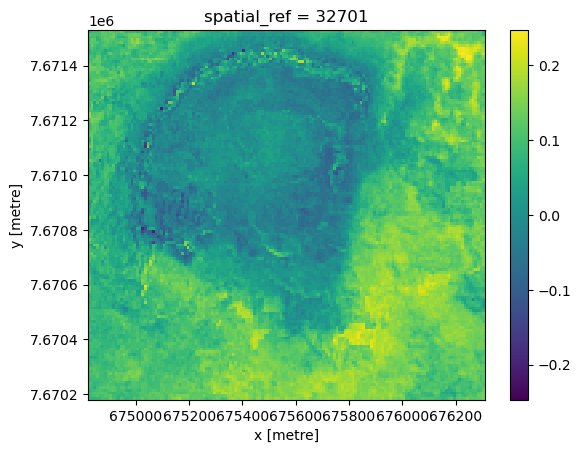

In [17]:
def calculate_lyzenga_dii(ds, band_i='blue', band_j='green'):
    """
    Calculates the Depth Invariant Index (DII) using the Lyzenga (1981) method.
    
    Parameters:
    ds: xr.Dataset containing Sentinel-2 bands
    band_i, band_j: Strings representing the bands to ratio (usually 'blue'/'green')
    """
    
    # 1. Natural Log Transform of the bands
    # We add a tiny offset to avoid log(0)
    li = np.log(ds[band_i].where(ds[band_i] > 0))
    lj = np.log(ds[band_j].where(ds[band_j] > 0))
    
    # 2. Calculate the Ratio of Attenuation (ki/kj)
    # In a full study, you would sample 'sand' pixels at different depths 
    # and find the slope of the regression line between li and lj.
    # For Fiji clear waters, ~0.8 to 1.1 is a common starting point for Blue/Green.
    
    # Example calculation of slope (ki/kj) if you have a sand mask:
    # slope = np.cov(li_sand, lj_sand) / np.var(lj_sand)
    
    ratio_ki_kj = 1.0  # Placeholder: replace with your calculated slope
    
    # 3. Compute DII
    dii = li - (ratio_ki_kj * lj)
    
    return dii

# Usage in DEP Notebook:
dii_map = calculate_lyzenga_dii(median)
dii_map.plot(cmap='viridis')

In [18]:
median

<xarray.Dataset> Size: 807kB
Dimensions:      (y: 135, x: 149)
Coordinates:
  * y            (y) float64 1kB 7.672e+06 7.672e+06 ... 7.67e+06 7.67e+06
  * x            (x) float64 1kB 6.748e+05 6.748e+05 ... 6.763e+05 6.763e+05
    spatial_ref  int32 4B 32701
Data variables:
    red          (y, x) float32 80kB 0.1434 0.1314 0.1268 ... 0.1146 0.1128
    green        (y, x) float32 80kB 0.1524 0.1392 0.1306 ... 0.1271 0.1271
    blue         (y, x) float32 80kB 0.1621 0.1516 0.1422 ... 0.1446 0.1465
    nir08        (y, x) float32 80kB 0.1333 0.1333 0.1237 ... 0.1168 0.1167
    swir16       (y, x) float32 80kB 0.1391 0.1391 0.1268 ... 0.118 0.118 0.1185
    scl          (y, x) float32 80kB 0.0006 0.0006 0.0006 ... 0.0006 0.0006
    rededge1     (y, x) float32 80kB 0.1383 0.1383 0.1239 ... 0.1162 0.1168
    ndvi         (y, x) float32 80kB 0.0004852 0.000227 ... -0.007977 -0.002421
    ndwi         (y, x) float32 80kB 0.01287 0.01575 0.02034 ... 0.06164 0.05474
    cmri         (y, x) float32 80kB -0.01674 -0.01381 ... -0.06538 -0.06623

In [19]:
ds = median

In [20]:
def calculate_masked_ndci(ds):
    """
    Calculates NDCI for Sentinel-2 data and masks out deep water.
    B5 = 705nm (Red Edge), B4 = 665nm (Red)
    """
    # 1. Calculate NDCI
    # Formula: (B5 - B4) / (B5 + B4)
    ndci = (ds.rededge1 - ds.red) / (ds.rededge1 + ds.red)
    
    # 2. Create a Deep Water Mask
    # NIR (B08) is absorbed almost immediately by water. 
    # Pixels with very low NIR are usually deep water or outside the reef flat.
    # Adjust 0.05 based on your specific Fiji scene's turbidity.
    deep_water_mask = ds.nir08 > 0.05
    
    # 3. Apply the mask
    masked_ndci = ndci.where(deep_water_mask)
    
    return masked_ndci

# Usage:
coral_health_index = calculate_masked_ndci(median)

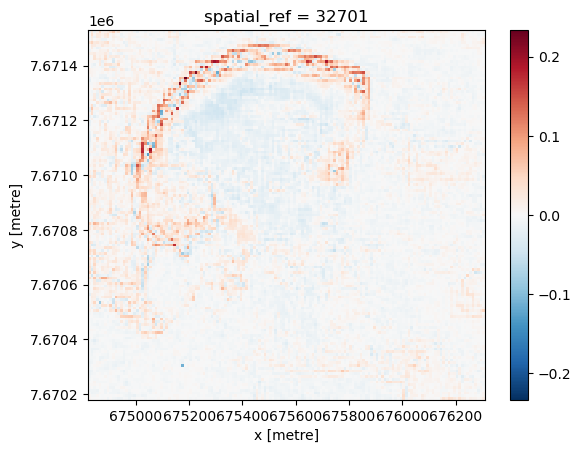

In [21]:
coral_health_index.plot()

In [22]:
import datetime

# Define the query
query = {
    'x': (178.5, 178.6), # Example coords for Bua/Vanua Levu
    'y': (-16.8, -16.9),
    'time': ('2020-01-01', str(datetime.date.today())), # 2020 to now
    'measurements': ['nbart_red', 'nbart_red_edge_1', 'nbart_nir_1'],
    'output_crs': 'EPSG:3460', # Fiji Map Grid
    'resolution': (-20, 20)    # Resampled to match Red Edge resolution
}

ds_time = data.load(product='ga_s2am_ard_3', **query)

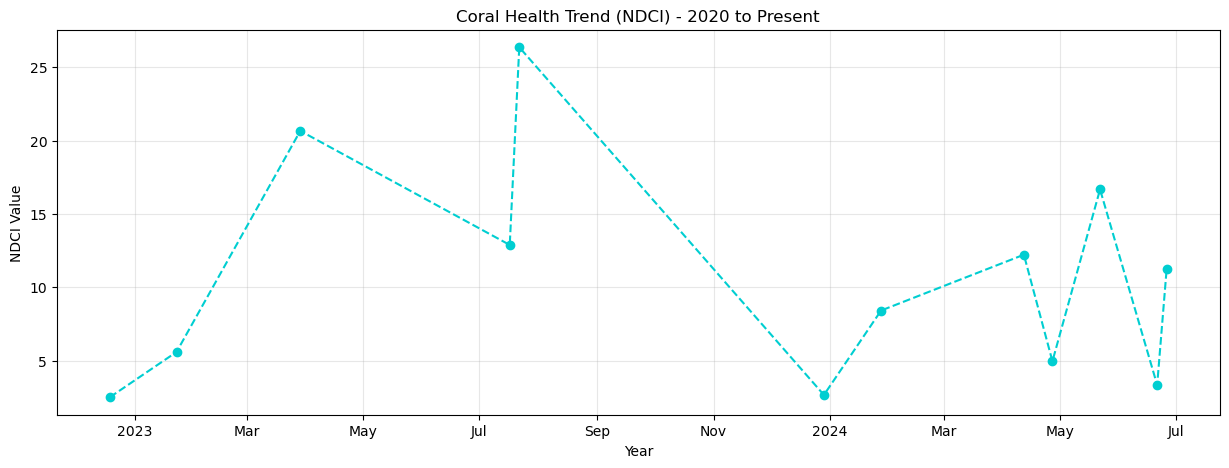

In [23]:
import matplotlib.pyplot as plt

# 1. Calculate NDCI (using the logic we defined earlier)
ds_time['ndci'] = (ds_time.rededge1 - ds_time.red) / (ds_time.rededge1 + ds_time.red)

# 2. Spatially average the NDCI across your whole study area (Y and X)
# This collapses the data into a 1D array indexed only by 'time'
ndci_timeseries = ds_time.ndci.mean(dim=['x', 'y'])

# 3. Plot with time on the X-axis
plt.figure(figsize=(15, 5))
ndci_timeseries.plot(marker='o', color='#00ced1', linestyle='--')

plt.title('Coral Health Trend (NDCI) - 2020 to Present')
plt.ylabel('NDCI Value')
plt.xlabel('Year')
plt.grid(alpha=0.3)
plt.show()

In [24]:
from pystac_client import Client
from odc.stac import load
import datetime

# 1. Connect to the V1 API
client = Client.open("https://earth-search.aws.element84.com/v1")

# 2. Set dynamic end date for today in 2026
today = datetime.date.today().strftime('%Y-%m-%d')

# 3. Search specifically for the 'sentinel-2-l2a' collection
search = client.search(
    collections=["sentinel-2-l2a"],
    bbox=[178.5, -16.9, 178.6, -16.8], # Example Bua/Fiji bbox
    datetime=f"2020-01-01/{today}",
    query={"eo:cloud_cover": {"lt": 20}} # Filter to keep the timesteps clean
)

# 4. Load into xarray
# Note: Use 'groupby="solar_day"' to prevent duplicate time slices from orbit overlaps
ds = load(
    search.items(),
    groupby="solar_day",
    chunks={"x": 2048, "y": 2048},
    bands=["red", "rededge1", 'nir08'] # Element 84 often uses 'rededge1' alias for B05
)

print(f"Latest timestamp found: {ds.time.max().values}")

Latest timestamp found: 2026-03-08T22:20:45.385000000


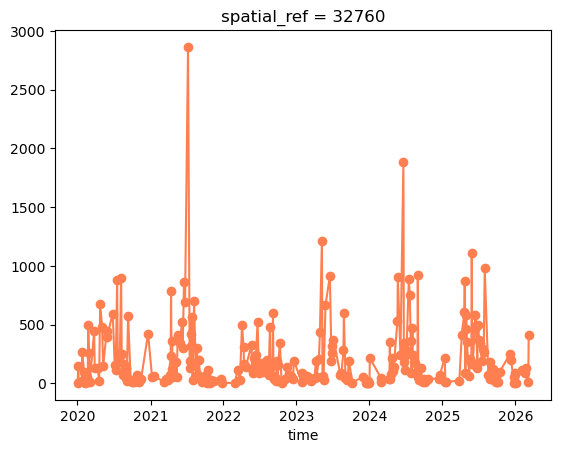

In [25]:
# 1. Add 'nir' to your bands list
ds = load(
    search.items(),
    groupby="solar_day",
    chunks={"x": 2048, "y": 2048},
    bands=["red", "rededge1", "nir"] # Red=B04, RedEdge1=B05, NIR=B08
)

# 2. Define your mask
# This identifies pixels that are definitely NOT deep sea
reef_mask = ds.nir > 0.04 

# 3. Calculate NDCI only where it's shallow enough
ndci = (ds.rededge1 - ds.red) / (ds.rededge1 + ds.red)
masked_ndci = ndci.where(reef_mask)

# 4. Plot the results
masked_ndci.mean(dim=['x', 'y']).plot(marker='o', color='coral')

Text(0.5, 1.0, 'Cleaned Coral Health Trend (NDCI)')

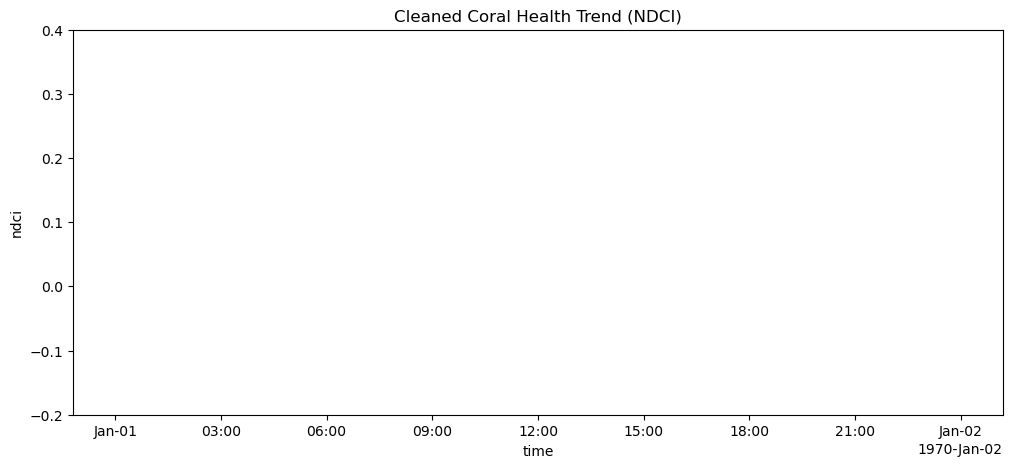

In [26]:
# Clip values to the valid spectral range before plotting
ndci_clean = ndci_timeseries.where((ndci_timeseries > -1) & (ndci_timeseries < 1))

# Plot again
plt.figure(figsize=(12, 5))
ndci_clean.plot(marker='o', color='coral')
plt.ylim(-0.2, 0.4) # Focus on the scientifically relevant range
plt.title("Cleaned Coral Health Trend (NDCI)")